In [ ]:


def cluster_blobs():


if __name__ == "__main__":
    cluster_blobs()

# Relevant Papers
>Tscherepanow, M. (2010).  
>TopoART: A Topology Learning Hierarchical ART Network.  
>In K. Diamantaras, W. Duch, & L. S. Iliadis (Eds.),  
>Artificial Neural Networks – ICANN 2010 (pp. 157–167).  
>Berlin, Heidelberg: Springer Berlin Heidelberg.  
>doi:10.1007/978-3-642-15825-4_21.  

# Import Necessary Libraries

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

from artlib import TopoART, FuzzyART

# Dataset Generation
In this example we use two fuzzy art models as the basis for Fusion Art

For this we use `sklearn` to generate a dataset consisting of 150 input vectors, each of length 2, with 3 centers.

In [ ]:
data, target = make_blobs(n_samples=150, centers=3, cluster_std=0.50, random_state=0, shuffle=False)
print("Data has shape:", data.shape)



Data has shape: (150, 2)


## Clustering with Topo ART

In the example below, we initalize the SMART model with the following parameters  

- `base_ART_class`: The base ART class SMART will base itself off of  
- `rho_values`: The rho values SMART will use for each layer, must be sequentially increasing  
- `base_params`: The base parameters that will be used by the base ART class


We then prepare the data using `prepare_data` and cluster the data using cls.fit  

After the clustering process, we can visualize the clusters using the `visualize` method.  

Prepared data has shape: (150, 4)


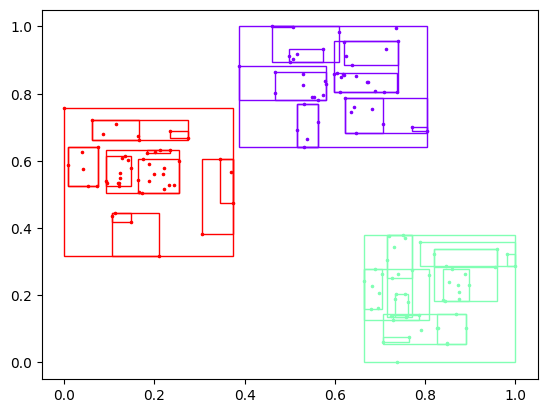

In [ ]:
params = {
    "rho": 0.4,
    "alpha": 0.8,
    "beta": 1.0
}
base_art = FuzzyART(**params)

X = base_art.prepare_data(data)
print("Prepared data has shape:", X.shape)

cls = TopoART(base_art, betta_lower=0.3, tau=150, phi=35)
cls = cls.fit(X, max_iter=5)
y = cls.labels_

print(f"{cls.n_clusters} clusters found")
print(f"{cls.base_module.n_clusters} internal clusters found")

print("Adjacency Matrix:")
print(cls.adjacency)

cls.visualize(X, y)
plt.show()
